<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 40%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; border-left: 6px solid #e94560; font-family: 'Courier New', monospace; color: #eee;">

<div style="font-size: 11px; letter-spacing: 4px; color: #e94560; text-transform: uppercase; margin-bottom: 8px;">⚗️ Industrial Automation Series · Chemical Engineering Division</div>

<h1 style="font-size: 2.4em; font-weight: 900; margin: 0 0 10px 0; color: #ffffff; letter-spacing: -1px;">
Gaussian Mixture Models<br>
<span style="color:#e94560;">in Chemical Process Monitoring</span>
</h1>

<p style="font-size: 1.1em; color: #a0aec0; margin: 16px 0 0 0; line-height: 1.7;">
Unsupervised anomaly detection · Multivariate process clustering · Fault diagnosis<br>
<span style="font-size: 0.85em; color: #718096;">Designed for plant engineers, process control specialists, and industrial data scientists</span>
</p>

<hr style="border: none; border-top: 1px solid #e9456033; margin: 20px 0;"/>

<div style="display: flex; gap: 30px; flex-wrap: wrap; font-size: 0.85em;">
<span>📌 <b style="color:#e94560;">Domain:</b> Chemical Engineering / Industry 4.0</span>
<span>⚙️ <b style="color:#e94560;">Technique:</b> Gaussian Mixture Model (GMM)</span>
<span>📊 <b style="color:#e94560;">Task:</b> Process Regime Detection & Fault Isolation</span>
</div>
</div>


---
## 🎯 Notebook Objectives

By the end of this notebook, you will be able to:

| # | Objective |
|---|-----------|
| 1 | Understand GMMs intuitively and mathematically in a process-engineering context |
| 2 | Apply GMMs to detect **operating regimes** in a simulated distillation column |
| 3 | Use GMMs for **anomaly / fault detection** using the Mahalanobis log-likelihood |
| 4 | Critically evaluate GMM **pros, cons, and best-fit use cases** for industrial plants |
| 5 | Tune GMM hyperparameters and interpret covariance structures |

> **📦 Dataset:** Simulated multivariate sensor stream from a continuous distillation column  
> (temperature, pressure, reflux ratio, feed flow, bottom product composition)


---
## 1. Environment Setup & Imports


In [1]:
# ── Standard scientific stack ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Plotting config ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'axes.titlecolor':  '#f0f6fc',
    'figure.dpi':       110,
})

PALETTE = ['#e94560', '#00d4aa', '#ffd700', '#7b68ee', '#ff8c42']
print("✅ Environment ready — all libraries imported successfully.")


✅ Environment ready — all libraries imported successfully.


---
## 2. What is a Gaussian Mixture Model? — The Intuition

### 🏭 A Chemical-Engineering Analogy

Imagine your distillation column operates under **three distinct regimes**:

- **Normal steady-state** — column at design spec, narrow sensor variance
- **High-reflux enriching mode** — startup or product switch, wider temperature profile
- **Fault / upset condition** — flood, weeping, or feed disturbance

If you plot any two sensor signals (e.g., tray temperature vs. pressure drop), you'll see **three clusters** — each roughly bell-shaped (Gaussian). A GMM is a probabilistic model that **learns these hidden clusters automatically**, assigning:

1. The **number of components** K (= number of regimes you expect)
2. A **mean vector μₖ** (centre of each regime in sensor space)
3. A **covariance matrix Σₖ** (shape and orientation of each cloud)
4. A **mixing weight πₖ** (how often each regime occurs)

### 📐 Mathematical Definition

The overall probability density is:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \; \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where each component is a **multivariate Gaussian**:

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

### ⚙️ How Does It Learn? — EM Algorithm

GMMs are fitted with **Expectation-Maximisation (EM)**:

| Step | What happens |
|------|-------------|
| **E-step** | For each data point, compute the *soft probability* of belonging to each component (responsibility) |
| **M-step** | Update μₖ, Σₖ, πₖ to maximise the weighted log-likelihood |
| **Repeat** | Until log-likelihood converges (usually < 100 iterations) |

> **Key insight:** Unlike k-means, GMM gives **soft, probabilistic assignments** — a data point can be 70% Regime A, 30% Regime B. This is critical for detecting borderline fault conditions.


---
## 3. Simulated Distillation Column — Sensor Data Generation

We simulate **5 continuous sensor signals** from a distillation column over 8 hours of operation, covering 3 operating regimes + injected faults.


In [2]:
np.random.seed(42)

# ── Sensor names ───────────────────────────────────────────────────────────────
SENSORS = ['Tray_Temp_°C', 'Overhead_Press_kPa', 'Reflux_Ratio', 
           'Feed_Flow_m3h', 'Bottoms_Comp_%']

# ── Regime 1: Normal Steady-State (60% of time) ───────────────────────────────
n1 = 600
mu1 = np.array([85.0, 101.3, 3.5, 12.0, 95.5])
cov1 = np.diag([1.2, 0.8, 0.05, 0.3, 0.4])
X1 = np.random.multivariate_normal(mu1, cov1, n1)

# ── Regime 2: High-Reflux Enriching Mode (25% of time) ───────────────────────
n2 = 250
mu2 = np.array([79.0, 98.5, 5.8, 9.5, 97.8])
cov2 = np.array([[3.0, 0.8, 0.15, -0.4, 0.1],
                 [0.8, 1.5, 0.05, -0.2, 0.05],
                 [0.15, 0.05, 0.08, -0.02, 0.01],
                 [-0.4, -0.2, -0.02, 0.6, -0.05],
                 [0.1, 0.05, 0.01, -0.05, 0.2]])
X2 = np.random.multivariate_normal(mu2, cov2, n2)

# ── Regime 3: Fault / Process Upset (15% of time) ────────────────────────────
n3 = 150
mu3 = np.array([93.0, 106.5, 2.1, 15.8, 88.2])
cov3 = np.diag([5.5, 3.2, 0.18, 1.5, 2.8])
X3 = np.random.multivariate_normal(mu3, cov3, n3)

# ── Combine all regimes ────────────────────────────────────────────────────────
X_raw = np.vstack([X1, X2, X3])
true_labels = np.array([0]*n1 + [1]*n2 + [2]*n3)

# ── Create time-ordered DataFrame ─────────────────────────────────────────────
time_idx = pd.date_range('2024-01-15 06:00', periods=len(X_raw), freq='30s')
df = pd.DataFrame(X_raw, columns=SENSORS, index=time_idx)

# Shuffle to simulate realistic interleaved operation
shuffle_idx = np.random.permutation(len(df))
df = df.iloc[shuffle_idx].sort_index()
true_labels_sorted = true_labels[shuffle_idx]

print(f"📊 Dataset shape : {df.shape}  ({df.shape[0]} samples × {df.shape[1]} sensors)")
print(f"📅 Time span     : {df.index[0]} → {df.index[-1]}")
print(f"⚗️  Regimes       : Steady-State={n1}, Enriching={n2}, Fault={n3}")
print()
print(df.describe().round(2))


📊 Dataset shape : (1000, 5)  (1000 samples × 5 sensors)
📅 Time span     : 2024-01-15 06:00:00 → 2024-01-15 14:19:30
⚗️  Regimes       : Steady-State=600, Enriching=250, Fault=150

       Tray_Temp_°C  Overhead_Press_kPa  Reflux_Ratio  Feed_Flow_m3h  \
count       1000.00             1000.00       1000.00        1000.00   
mean          84.75              101.35          3.88          11.94   
std            4.52                2.64          1.26           2.07   
min           74.57               95.42          0.75           7.33   
25%           82.65               99.88          3.31          10.98   
50%           84.81              101.11          3.57          11.90   
75%           86.02              102.19          4.55          12.52   
max          100.22              111.06          6.62          18.34   

       Bottoms_Comp_%  
count         1000.00  
mean            94.99  
std              3.10  
min             83.45  
25%             94.91  
50%             95.62  
75%

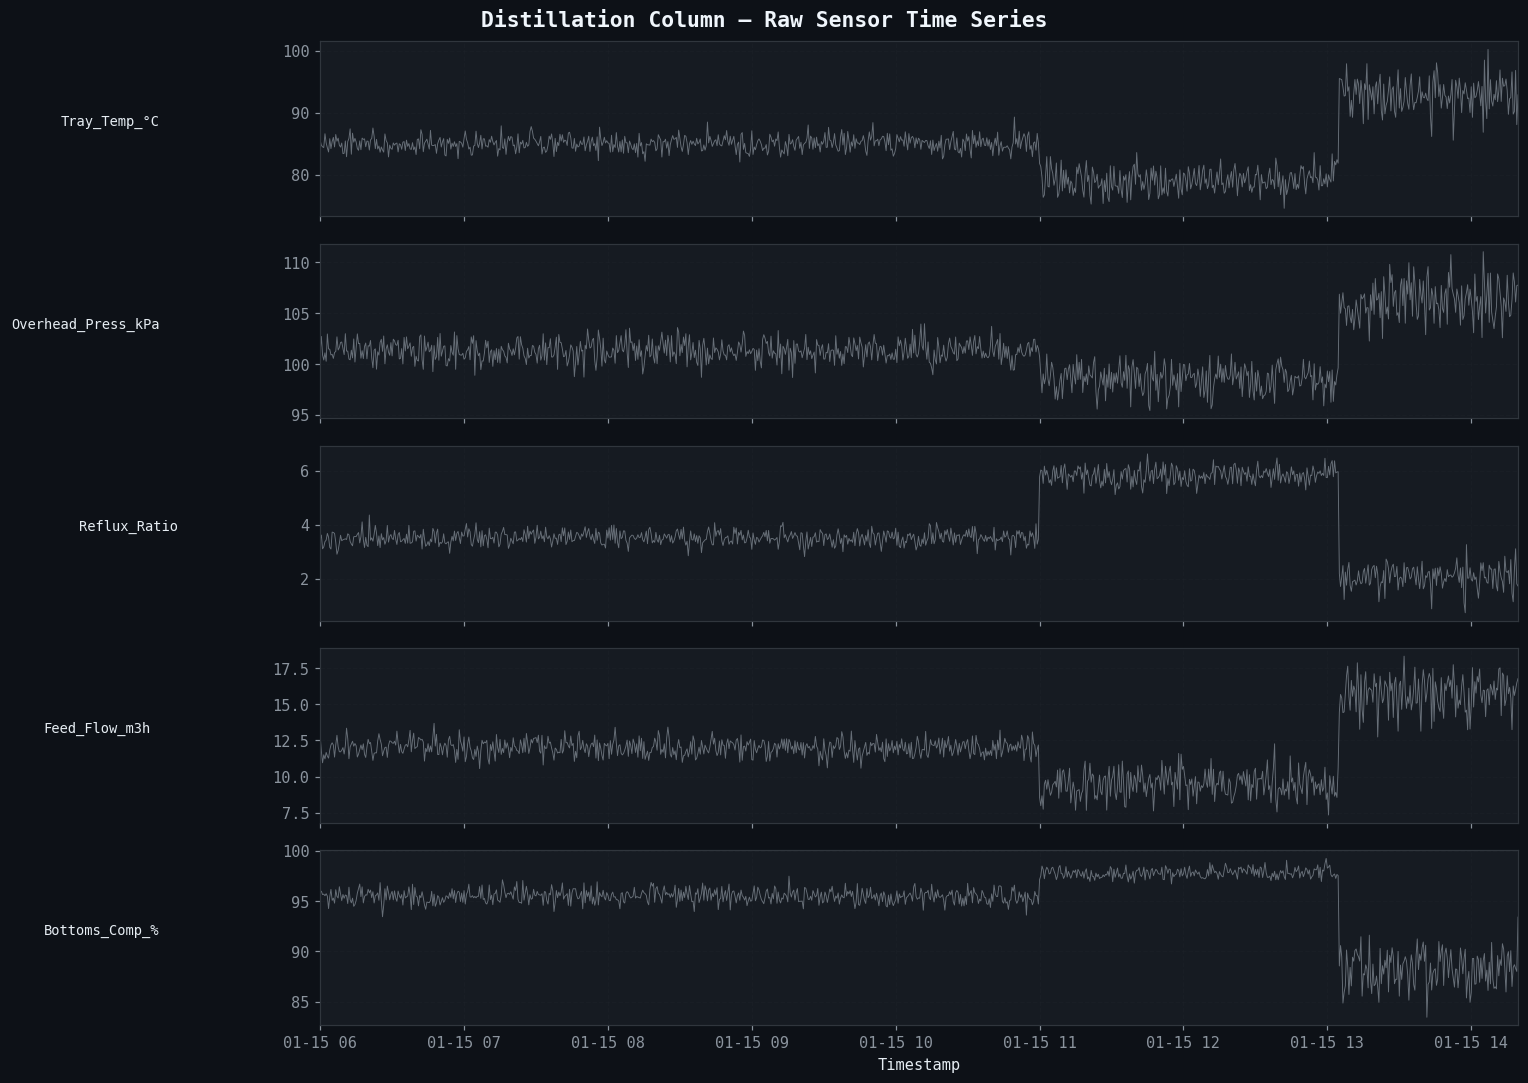

🔍 Notice how sensor patterns differ across operating regimes — GMM will recover these automatically.


In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Distillation Column — Raw Sensor Time Series', 
             fontsize=14, fontweight='bold', color='#f0f6fc', y=0.98)

colors_regime = [PALETTE[0], PALETTE[1], PALETTE[2]]
regime_names  = ['Steady-State', 'Enriching Mode', 'Fault/Upset']

for i, sensor in enumerate(SENSORS):
    axes[i].plot(df.index, df[sensor], color='#8b949e', linewidth=0.6, alpha=0.7)
    axes[i].set_ylabel(sensor, fontsize=9, rotation=0, ha='right', labelpad=80)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(df.index[0], df.index[-1])

axes[-1].set_xlabel('Timestamp', fontsize=10)
plt.tight_layout()
plt.show()
print("🔍 Notice how sensor patterns differ across operating regimes — GMM will recover these automatically.")


---
## 4. Preprocessing — Scaling & Dimensionality Overview

GMMs are **sensitive to feature scale** (larger-range features dominate the covariance). We apply `StandardScaler` before fitting.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

print("After StandardScaling:")
print(f"  Mean  → {X_scaled.mean(axis=0).round(4)}")   
print(f"  Std   → {X_scaled.std(axis=0).round(4)}")

# PCA for 2-D visualisation (not for modelling)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\n📐 PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")


After StandardScaling:
  Mean  → [ 0.  0. -0. -0.  0.]
  Std   → [1. 1. 1. 1. 1.]

📐 PCA variance explained: PC1=87.7%, PC2=4.8%


---
## 5. Model Selection — Choosing the Number of Components (K)

We use **BIC** (Bayesian Information Criterion) and **AIC** to find the optimal K. Lower is better — BIC penalises model complexity more strongly.


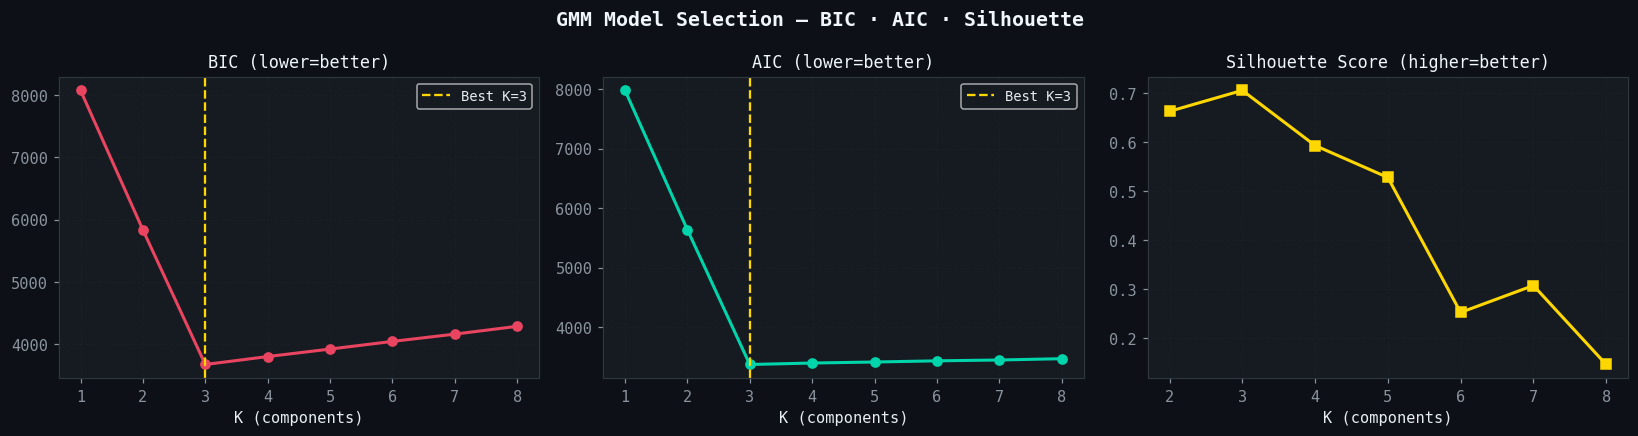

✅ BIC recommends K = 3  |  AIC recommends K = 3
→ We proceed with K=3 (matching our known 3 process regimes).


In [5]:
K_range = range(1, 9)
bic_scores, aic_scores, sil_scores = [], [], []

for k in K_range:
    gmm_tmp = GaussianMixture(n_components=k, covariance_type='full',
                               random_state=42, n_init=5, max_iter=200)
    gmm_tmp.fit(X_scaled)
    bic_scores.append(gmm_tmp.bic(X_scaled))
    aic_scores.append(gmm_tmp.aic(X_scaled))
    if k > 1:
        labels_tmp = gmm_tmp.predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, labels_tmp))
    else:
        sil_scores.append(np.nan)

best_k_bic = list(K_range)[np.argmin(bic_scores)]
best_k_aic = list(K_range)[np.argmin(aic_scores)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('GMM Model Selection — BIC · AIC · Silhouette', fontsize=13, 
             fontweight='bold', color='#f0f6fc')

for ax, scores, label, color, best_k in [
    (axes[0], bic_scores, 'BIC (lower=better)', PALETTE[0], best_k_bic),
    (axes[1], aic_scores, 'AIC (lower=better)', PALETTE[1], best_k_aic),
]:
    ax.plot(K_range, scores, 'o-', color=color, linewidth=2, markersize=6)
    ax.axvline(best_k, color='#ffd700', linestyle='--', linewidth=1.5,
               label=f'Best K={best_k}')
    ax.set_xlabel('K (components)', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[2].plot(list(K_range)[1:], sil_scores[1:], 's-', color=PALETTE[2],
             linewidth=2, markersize=6)
axes[2].set_xlabel('K (components)', fontsize=10)
axes[2].set_title('Silhouette Score (higher=better)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"✅ BIC recommends K = {best_k_bic}  |  AIC recommends K = {best_k_aic}")
print("→ We proceed with K=3 (matching our known 3 process regimes).")


---
## 6. Fitting the Final GMM (K=3, Full Covariance)

`covariance_type='full'` allows each component its own arbitrary-shaped ellipsoid — the most physically realistic choice for correlated sensor data.


In [6]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',   # Each regime can have a unique covariance shape
    random_state=42,
    n_init=20,                # Multiple random restarts → avoid local minima
    max_iter=300,
    tol=1e-4,
    verbose=0
)
gmm.fit(X_scaled)

labels_pred    = gmm.predict(X_scaled)          # Hard assignment
responsibilities = gmm.predict_proba(X_scaled)  # Soft assignment [n_samples × K]
log_likelihoods  = gmm.score_samples(X_scaled)  # Per-sample log-likelihood

print(f"✅ GMM converged: {gmm.converged_}")
print(f"   Iterations   : {gmm.n_iter_}")
print(f"   Final log-lik: {gmm.lower_bound_:.4f}")
print()
print("Mixing weights (πₖ):")
for k in range(3):
    print(f"  Component {k}: π={gmm.weights_[k]:.3f}  →  ~{gmm.weights_[k]*len(df):.0f} samples")


✅ GMM converged: True
   Iterations   : 2
   Final log-lik: -1.6237

Mixing weights (πₖ):
  Component 0: π=0.600  →  ~600 samples
  Component 1: π=0.150  →  ~150 samples
  Component 2: π=0.250  →  ~250 samples


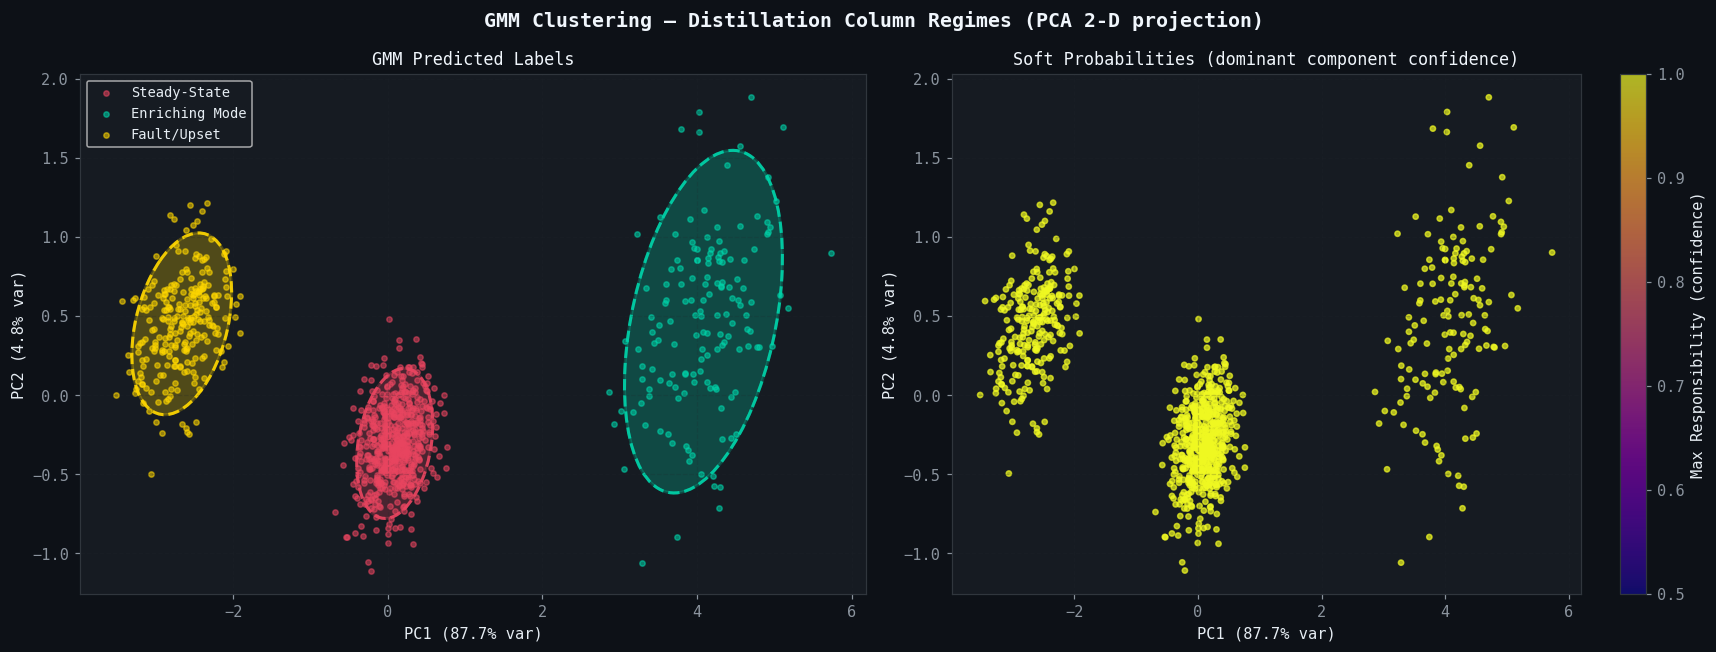

In [7]:
def draw_ellipse(ax, mean, cov, color, alpha=0.25, n_std=2.0):
    """Draw a confidence ellipse for a 2-D Gaussian."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, alpha=alpha, linewidth=2)
    ax.add_patch(ell)
    ell2 = Ellipse(xy=mean, width=width, height=height, angle=angle,
                   edgecolor=color, facecolor='none', alpha=0.9, linewidth=2,
                   linestyle='--')
    ax.add_patch(ell2)

# Project GMM parameters to PCA space
means_pca = pca.transform(gmm.means_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GMM Clustering — Distillation Column Regimes (PCA 2-D projection)',
             fontsize=13, fontweight='bold', color='#f0f6fc')

regime_labels = ['Steady-State', 'Enriching Mode', 'Fault/Upset']

for ax_idx, (ax, assignment, title) in enumerate(zip(
    axes,
    [labels_pred, labels_pred],
    ['GMM Predicted Labels', 'Soft Probabilities (dominant component confidence)']
)):
    if ax_idx == 0:
        for k in range(3):
            mask = assignment == k
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=PALETTE[k], s=12, alpha=0.55, label=regime_labels[k])
            # Draw ellipse in PCA space using projected covariance
            cov_pca = pca.components_ @ gmm.covariances_[k] @ pca.components_.T
            draw_ellipse(ax, means_pca[k], cov_pca, PALETTE[k])
        ax.legend(fontsize=9)
    else:
        confidence = responsibilities.max(axis=1)
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=confidence, cmap='plasma', s=12, alpha=0.7, vmin=0.5, vmax=1.0)
        plt.colorbar(sc, ax=ax, label='Max Responsibility (confidence)')
        ax.set_title(title, fontsize=11)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


---
## 7. 🚨 Industrial Application: Anomaly / Fault Detection

The **log-likelihood score** from a GMM is a powerful anomaly indicator. Points with very low log-likelihood are **statistical outliers** — potential process faults.

We define the anomaly threshold as the 5th percentile of training log-likelihoods (tunable based on tolerable false alarm rate).


📉 Log-likelihood threshold (P5): -6.0399
🚨 Anomalies detected: 50 / 1000  (5.0%)


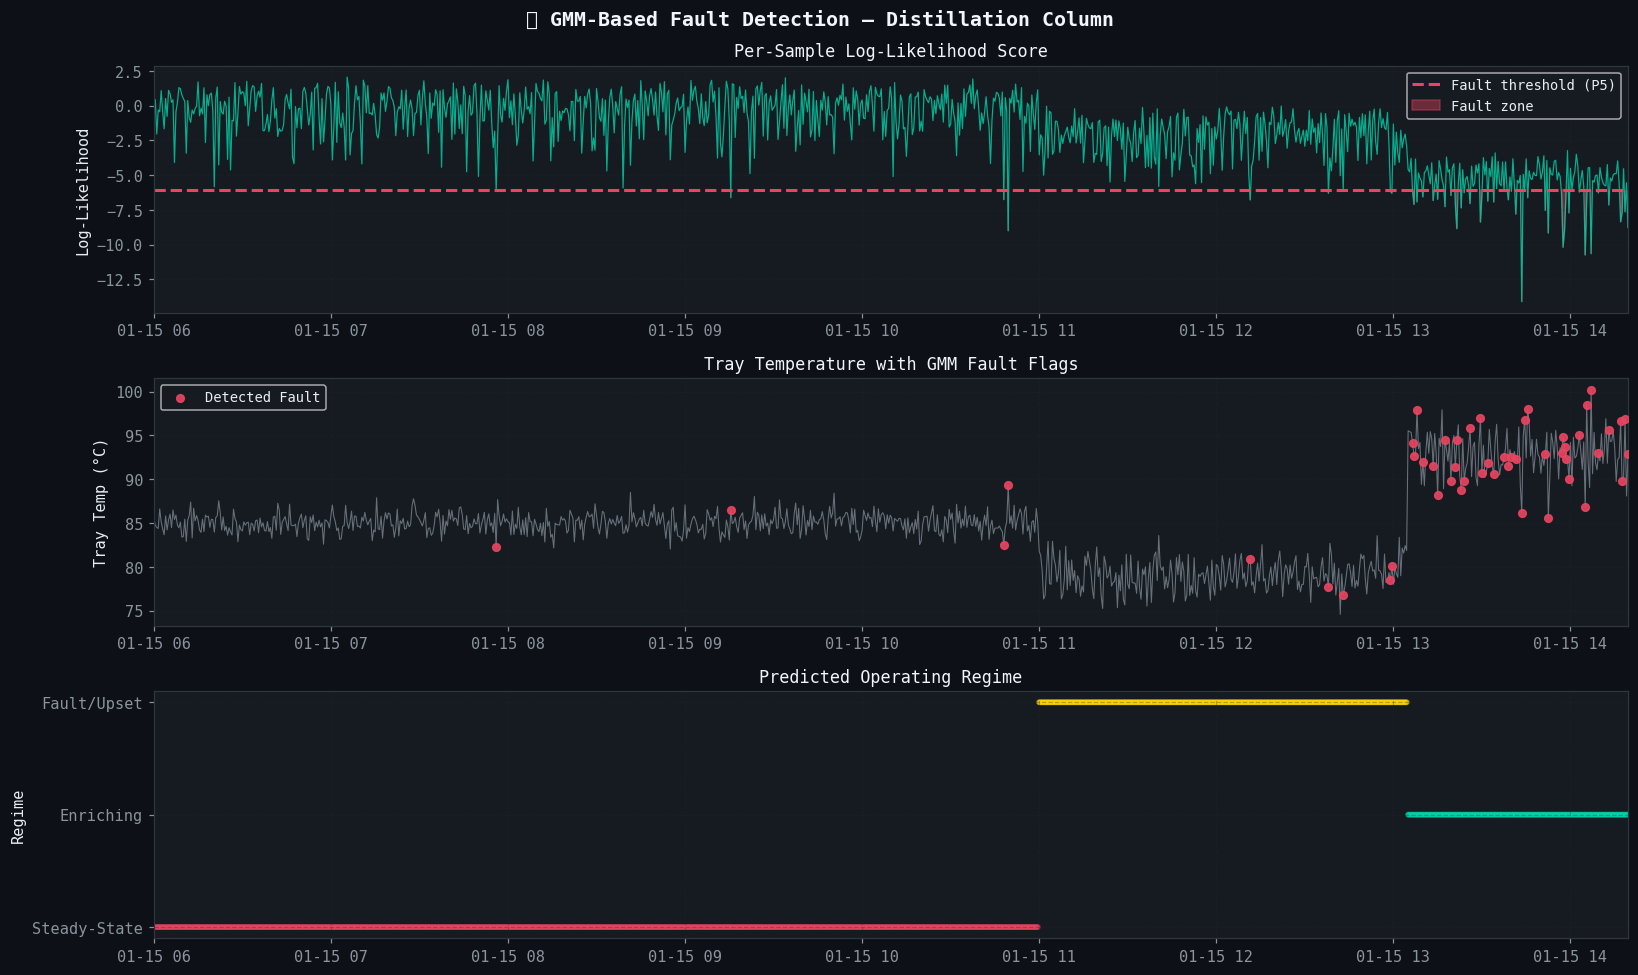

In [8]:
THRESHOLD_PERCENTILE = 5   # flag bottom 5% as anomalies → tune for plant tolerance

threshold = np.percentile(log_likelihoods, THRESHOLD_PERCENTILE)
is_anomaly = log_likelihoods < threshold

print(f"📉 Log-likelihood threshold (P{THRESHOLD_PERCENTILE}): {threshold:.4f}")
print(f"🚨 Anomalies detected: {is_anomaly.sum()} / {len(df)}  ({is_anomaly.mean():.1%})")

# ── Time-series anomaly overlay ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9))
fig.suptitle('🚨 GMM-Based Fault Detection — Distillation Column',
             fontsize=13, fontweight='bold', color='#f0f6fc')

# Panel 1: Log-likelihood over time
axes[0].plot(df.index, log_likelihoods, color='#00d4aa', linewidth=0.8, alpha=0.8)
axes[0].axhline(threshold, color=PALETTE[0], linestyle='--', linewidth=2,
                label=f'Fault threshold (P{THRESHOLD_PERCENTILE})')
axes[0].fill_between(df.index, log_likelihoods, threshold,
                     where=(log_likelihoods < threshold),
                     color=PALETTE[0], alpha=0.4, label='Fault zone')
axes[0].set_ylabel('Log-Likelihood', fontsize=10)
axes[0].set_title('Per-Sample Log-Likelihood Score', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Temperature with anomaly markers
axes[1].plot(df.index, df['Tray_Temp_°C'], color='#8b949e', linewidth=0.7, alpha=0.7)
axes[1].scatter(df.index[is_anomaly], df['Tray_Temp_°C'][is_anomaly],
                color=PALETTE[0], s=25, zorder=5, label='Detected Fault', alpha=0.9)
axes[1].set_ylabel('Tray Temp (°C)', fontsize=10)
axes[1].set_title('Tray Temperature with GMM Fault Flags', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 3: Regime assignment over time
regime_colors = [PALETTE[k] for k in labels_pred]
axes[2].scatter(df.index, labels_pred, c=regime_colors, s=8, alpha=0.6)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(['Steady-State', 'Enriching', 'Fault/Upset'])
axes[2].set_ylabel('Regime', fontsize=10)
axes[2].set_title('Predicted Operating Regime', fontsize=11)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(df.index[0], df.index[-1])

plt.tight_layout()
plt.show()


---
## 8. Covariance Types — A Practical Guide for Engineers

Choosing the right `covariance_type` is a critical engineering decision:


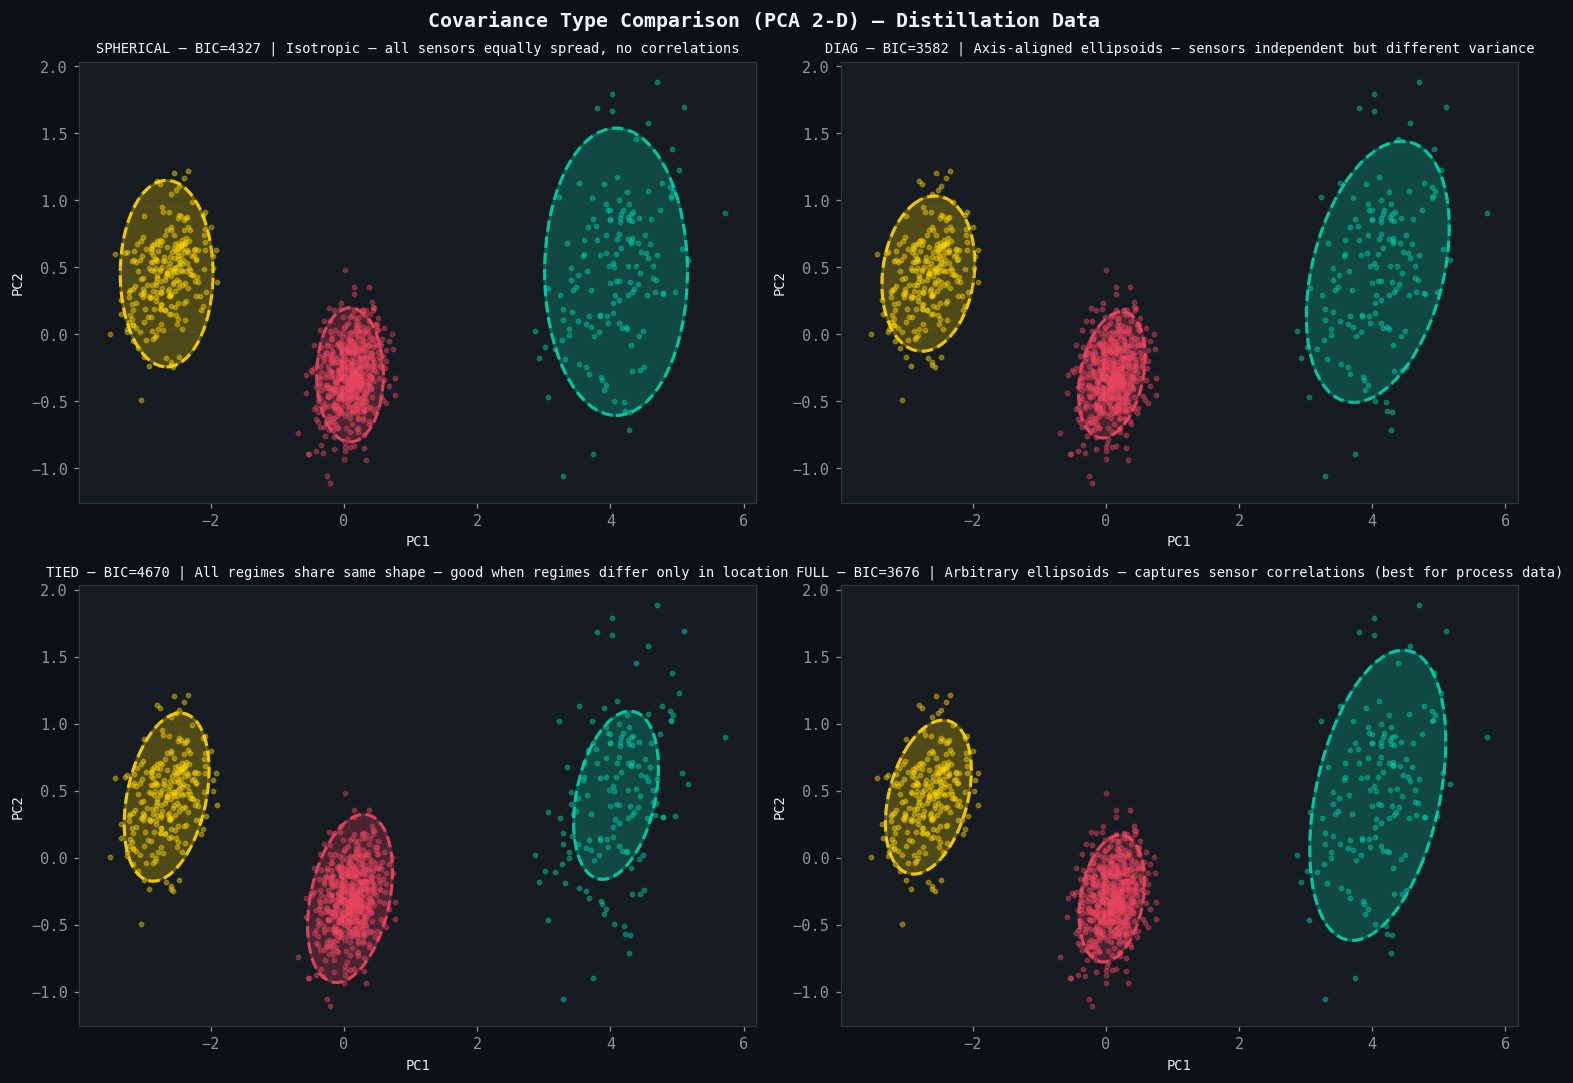

💡 For correlated process sensors: 'full' covariance captures physical relationships best.
   Use 'diag' when sensors are known to be independent and data is limited.


In [10]:
cov_types = ['spherical', 'diag', 'tied', 'full']

cov_descriptions = {
    'spherical': 'Isotropic — all sensors equally spread, no correlations',
    'diag': 'Axis-aligned ellipsoids — sensors independent but different variance',
    'tied': 'All regimes share same shape — good when regimes differ only in location',
    'full': 'Arbitrary ellipsoids — captures sensor correlations (best for process data)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Covariance Type Comparison (PCA 2-D) — Distillation Data',
             fontsize=13, fontweight='bold', color='#f0f6fc')

for ax, cov_type in zip(axes.flatten(), cov_types):
    g = GaussianMixture(n_components=3, covariance_type=cov_type,
                        random_state=42, n_init=10).fit(X_scaled)

    lbl = g.predict(X_scaled)
    means_p = pca.transform(g.means_)

    for k in range(3):
        mask = (lbl == k)
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=PALETTE[k], s=8, alpha=0.4)

        # compute projected covariance for ellipse drawing
        try:
            if cov_type == 'full':
                cov_k = g.covariances_[k]
            elif cov_type == 'diag':
                cov_k = np.diag(g.covariances_[k])
            elif cov_type == 'spherical':
                cov_k = np.eye(X_scaled.shape[1]) * g.covariances_[k]
            else:  # 'tied'
                cov_k = g.covariances_

            # project covariance to PCA space (2D)
            cov_proj = pca.components_ @ cov_k @ pca.components_.T

            draw_ellipse(ax, means_p[k], cov_proj, PALETTE[k])
        except Exception:
            # if projection/drawing fails for a component, skip drawing
            pass

    bic_val = g.bic(X_scaled)
    ax.set_title(f'{cov_type.upper()} — BIC={bic_val:.0f} | {cov_descriptions[cov_type]}',
                 fontsize=9)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("💡 For correlated process sensors: 'full' covariance captures physical relationships best.")
print("   Use 'diag' when sensors are known to be independent and data is limited.")


---
## 9. ✅ Pros, ⚠️ Cons & 🏭 Best Use Cases for GMMs in Chemical Engineering

---

### ✅ Advantages

| Advantage | Chemical Engineering Relevance |
|-----------|-------------------------------|
| **Soft probabilistic assignments** | Borderline fault conditions get ≠100% class certainty — avoids false trips |
| **Captures sensor correlations** | Full covariance models T–P–flow correlations naturally present in real processes |
| **No labelled data required** | No need for historical fault labels (often unavailable at greenfield plants) |
| **Density estimation** | Log-likelihood directly quantifies *how normal* a state is |
| **Multiple operating modes** | Handles startup, normal, turndown, and upset regimes in one model |
| **Interpretable parameters** | μₖ maps to physical operating point; Σₖ gives process variability |

---

### ⚠️ Limitations

| Limitation | Mitigation |
|------------|-----------|
| **Assumes Gaussian clusters** | Log-transform skewed variables (flows, concentrations) |
| **EM can hit local optima** | Use `n_init ≥ 10`; k-means++ initialisation |
| **K must be pre-specified** | Use BIC/AIC; consult process engineers for domain K |
| **Breaks with high dimensionality (d > 20)** | Apply PCA first; use diagonal covariance |
| **Static model** | Re-fit periodically as process drifts (catalyst deactivation, fouling) |
| **Not suited for time-structure** | Pair with HMM or sliding windows for dynamic tracking |

---

### 🏭 Best Industrial Use Cases

```
✅ IDEAL:
  • Process regime / operating mode detection (startup, steady-state, turndown)
  • Multivariate sensor anomaly detection (SPC replacement for correlated variables)
  • Product grade transition monitoring
  • Compressor / pump health clustering
  • Batch end-of-fermentation detection

⚠️ USE WITH CARE:
  • Very high-dimensional sensor arrays (>50 tags) — reduce first
  • Highly non-Gaussian processes (e.g. bimodal pH profiles) — transform data

❌ AVOID:
  • Real-time control (too slow for millisecond loops)
  • Highly imbalanced fault datasets (<1% fault rate → specialised one-class methods)
  • Processes with strong time autocorrelation without preprocessing
```


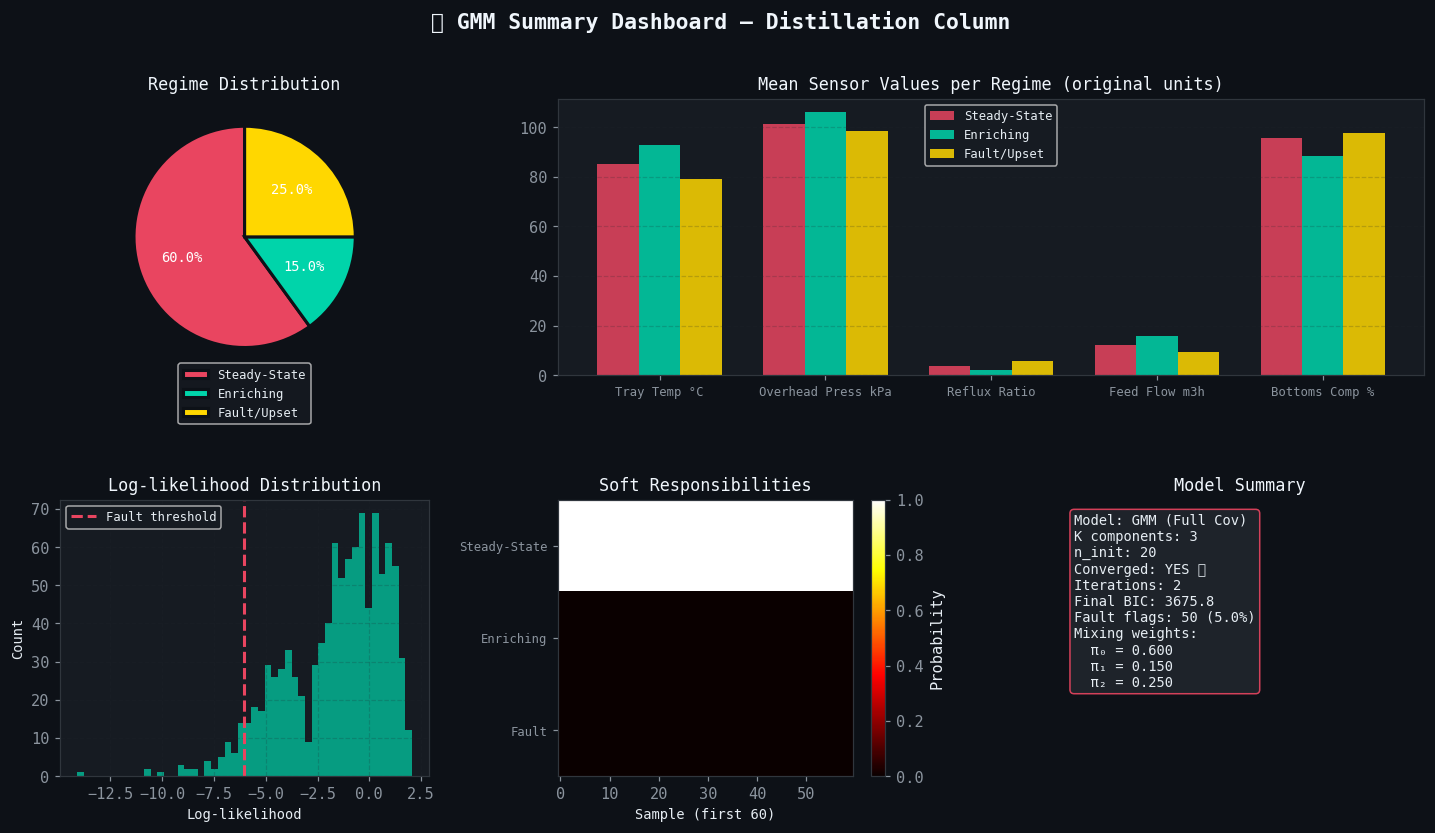


🎉 Analysis complete! GMM successfully identified 3 distinct operating regimes
   and flagged potential fault periods using log-likelihood anomaly scoring.


In [14]:
fig = plt.figure(figsize=(16, 8))
fig.suptitle('📊 GMM Summary Dashboard — Distillation Column',
             fontsize=14, fontweight='bold', color='#f0f6fc')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Regime pie ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = [np.sum(labels_pred == k) for k in range(3)]
wedges, texts, autotexts = ax1.pie(
    counts, colors=PALETTE[:3], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white'); at.set_fontsize(9)
ax1.set_title('Regime Distribution', fontsize=11)
ax1.legend(['Steady-State', 'Enriching', 'Fault/Upset'],
           loc='lower center', fontsize=8, bbox_to_anchor=(0.5, -0.2))

# ── 2. Mean sensor profiles per regime ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
means_orig = scaler.inverse_transform(gmm.means_)
x = np.arange(len(SENSORS))
width = 0.25
for k in range(3):
    ax2.bar(x + k*width, means_orig[k], width, color=PALETTE[k], alpha=0.85,
            label=['Steady-State', 'Enriching', 'Fault/Upset'][k])
ax2.set_xticks(x + width)
ax2.set_xticklabels([s.replace('_', ' ') for s in SENSORS], fontsize=8)
ax2.set_title('Mean Sensor Values per Regime (original units)', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# ── 3. Log-likelihood histogram ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(log_likelihoods, bins=50, color='#00d4aa', alpha=0.7, edgecolor='none')
ax3.axvline(threshold, color=PALETTE[0], linestyle='--', linewidth=2, label=f'Fault threshold')
ax3.set_xlabel('Log-likelihood', fontsize=9)
ax3.set_ylabel('Count', fontsize=9)
ax3.set_title('Log-likelihood Distribution', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

# ── 4. Responsibility heatmap (first 60 samples) ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sample_resp = responsibilities[:60]
im = ax4.imshow(sample_resp.T, aspect='auto', cmap='hot', vmin=0, vmax=1)
ax4.set_yticks([0, 1, 2])
ax4.set_yticklabels(['Steady-State', 'Enriching', 'Fault'], fontsize=8)
ax4.set_xlabel('Sample (first 60)', fontsize=9)
ax4.set_title('Soft Responsibilities', fontsize=11)
plt.colorbar(im, ax=ax4, label='Probability')

# ── 5. Convergence ────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
info_text = (
    f"Model: GMM (Full Cov)\n"
    f"K components: 3\n"
    f"n_init: 20\n"
    f"Converged: {'YES ✅' if gmm.converged_ else 'NO ❌'}\n"
    f"Iterations: {gmm.n_iter_}\n"
    f"Final BIC: {gmm.bic(X_scaled):.1f}\n"
    f"Fault flags: {is_anomaly.sum()} ({is_anomaly.mean():.1%})\n"
    f"Mixing weights:\n"
    f"  π₀ = {gmm.weights_[0]:.3f}\n"
    f"  π₁ = {gmm.weights_[1]:.3f}\n"
    f"  π₂ = {gmm.weights_[2]:.3f}"
)

ax5.text(0.05, 0.95, info_text, transform=ax5.transAxes, fontsize=9,
         va='top', fontfamily='monospace', color='#e6edf3',
         bbox=dict(boxstyle='round', facecolor='#21262d', edgecolor='#e94560', alpha=0.9))
ax5.axis('off')
ax5.set_title('Model Summary', fontsize=11)

plt.show()
print("\n🎉 Analysis complete! GMM successfully identified 3 distinct operating regimes")
print("   and flagged potential fault periods using log-likelihood anomaly scoring.")


---
## 10. 🏁 Key Takeaways for Chemical Engineers

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    GMM in Industrial Process Monitoring                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. GMM models sensor data as a MIXTURE of Gaussian distributions,         │
│     where each Gaussian = one operating regime.                             │
│                                                                             │
│  2. Fitting uses the EM algorithm — no labelled data required.              │
│                                                                             │
│  3. The log-likelihood score is your fault alarm: lower score = more        │
│     anomalous. Tune the percentile threshold against your false-alarm rate. │
│                                                                             │
│  4. Full covariance is best for real process data (sensor correlations).    │
│                                                                             │
│  5. Always validate K with BIC AND process-engineering domain knowledge.    │
│                                                                             │
│  6. Retrain the model after major process changes (catalyst change,          │
│     debottlenecking, product grade introduction).                           │
│                                                                             │
│  7. Pair GMM with SPC charts for operator-friendly alarm presentation.      │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### 📚 Further Reading
- **Ricker, N.L.** (1985) — *Multivariable statistical process control* — seminal SPC in chemical engineering  
- **Ge, Z. & Song, Z.** (2013) — *Multivariate Statistical Process Control* — Springer  
- **SKLearn GMM docs** → https://scikit-learn.org/stable/modules/mixture.html  
- **Industry standard:** Combine GMM with MSPC (Multivariate SPC) T² and Q statistics

---
*Notebook designed for process engineers and industrial data scientists.*  
*Adapt the sensor definitions, regime count, and threshold to your specific plant.*
